# Sanskrit → English Neural Machine Translation

This notebook implements my end-to-end Sanskrit → English neural machine translation system. The system follows a sequence-to-sequence architecture — a Transformer encoder–decoder with cross-attention and beam-search decoding — which I adapt to the Sanskrit→English task using the provided parallel train/dev/test data, then use to generate the required `submission.csv`.


In [1]:
%pip install -q peft==0.11.1

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Setup cell: install the libraries used in this experiment
# Recommended environment: Python 3.10 or 3.11. Avoid Python 3.13.

!pip install -q torch "transformers==4.40.2" "tokenizers==0.19.1" "accelerate==0.30.1" sentencepiece sacremoses nltk bert-score pandas numpy tqdm matplotlib scikit-learn "peft==0.11.1"
!pip install -q git+https://github.com/VarunGumma/IndicTransToolkit.git


In [2]:
# Imports and deterministic seed setup
import os
import re
import json
import time
import random
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, get_linear_schedule_with_warmup
from torch.optim import AdamW
from nltk.translate.bleu_score import corpus_bleu
from bert_score import score as bertscore

try:
    from peft import LoraConfig, get_peft_model, TaskType, PeftModel
    _PEFT_AVAILABLE = True
except ModuleNotFoundError:
    LoraConfig = get_peft_model = TaskType = PeftModel = None
    _PEFT_AVAILABLE = False
    print("Note: 'peft' not installed. Full fine-tuning works; set USE_LORA=True only after installing peft.")

try:
    from IndicTransToolkit import IndicProcessor
except Exception:
    from IndicTransToolkit.processor import IndicProcessor

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)


Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
CUDA: 12.6


In [3]:
# Experiment configuration
MODEL_NAME = "ai4bharat/indictrans2-indic-en-dist-200M"
SRC_LANG = "san_Deva"
TGT_LANG = "eng_Latn"

NUM_EPOCHS = 6
LEARNING_RATE = 3e-5
WEIGHT_DECAY = 0.01
TRAIN_BATCH_SIZE = 4       # lower to 2 if CUDA OOM
EVAL_BATCH_SIZE = 4
INFER_BATCH_SIZE = 8
MAX_SOURCE_LENGTH = 128
MAX_TARGET_LENGTH = 128
MAX_NEW_TOKENS = 128
NUM_BEAMS = 5
LENGTH_PENALTY = 1.0
NO_REPEAT_NGRAM_SIZE = 0
GRAD_CLIP_NORM = 1.0
PATIENCE = 2
LABEL_SMOOTHING = 0.1


USE_LORA = True
LORA_RANK = 32                                                    
LORA_ALPHA = 64                                                   
LORA_DROPOUT = 0.05
LORA_LR = 3e-4                                                    
LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "out_proj", "fc1", "fc2"]  

EFFECTIVE_LR = LORA_LR if USE_LORA else LEARNING_RATE

EVAL_DEV_BLEU_EACH_EPOCH = True
DEV_BLEU_LIMIT = None
USE_FP16 = torch.cuda.is_available()
OUTPUT_DIR = Path("indictrans2_clean_best_model")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Output directory:", OUTPUT_DIR.resolve())
print("Fine-tuning mode:", "LoRA (PEFT)" if USE_LORA else "full fine-tune")
print("Effective learning rate:", EFFECTIVE_LR)


Output directory: C:\Users\sunny\Downloads\G25AIT1151_NLU_Neural_Machine_Translatiion_Assignment_v8\indictrans2_clean_best_model
Fine-tuning mode: LoRA (PEFT)
Effective learning rate: 0.0003


In [4]:
def find_file(*names):
    """Find a file in current folder, /mnt/data, or common Colab drive locations."""
    search_roots = [
        Path.cwd(),
        Path("/mnt/data"),
        Path("/content"),
        Path("/content/drive/MyDrive"),
        Path("/content/drive/MyDrive/Data_to_Students"),
    ]
    for root in search_roots:
        for name in names:
            p = root / name
            if p.exists():
                return p
    raise FileNotFoundError(f"Could not find any of: {names}")

def read_csv_flexible(path):
    try:
        return pd.read_csv(path, encoding="utf-8")
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="utf-8-sig")

def normalise_col_name(c):
    return re.sub(r"[^a-z0-9]+", "", str(c).lower())

def find_col(df, *candidates):
    lookup = {normalise_col_name(c): c for c in df.columns}
    for cand in candidates:
        key = normalise_col_name(cand)
        if key in lookup:
            return lookup[key]
    raise KeyError(f"Could not find any of {candidates}. Available columns: {list(df.columns)}")

def normalize_text(x):
    x = unicodedata.normalize("NFC", str(x))
    x = re.sub(r"\s+", " ", x).strip()
    return x

def standardise_sa(df):
    id_col = find_col(df, "Source id", "Source_id", "id")
    sa_col = find_col(df, "Sentence sa", "Sentence_sa", "sa", "source")
    out = df[[id_col, sa_col]].copy()
    out.columns = ["Source id", "Sentence sa"]
    out["Sentence sa"] = out["Sentence sa"].map(normalize_text)
    return out

def standardise_en(df):
    id_col = find_col(df, "Source id", "Source_id", "id")
    en_col = find_col(df, "Sentence en", "Sentence_en", "en", "target")
    out = df[[id_col, en_col]].copy()
    out.columns = ["Source id", "Sentence en"]
    out["Sentence en"] = out["Sentence en"].map(normalize_text)
    return out

## Data alignment check
The Sanskrit and English files are separate, so I first align them by `Source id`. I keep this step explicit because any mismatch here would directly corrupt the translation pairs.


In [5]:
# Load CSV files and align source-target rows
train_sa_path = find_file("train_sa_10000.csv", "train_sa.csv")
train_en_path = find_file("train_en_10000.csv", "train_en.csv")
dev_sa_path   = find_file("dev_sa_1000.csv", "dev_sa.csv")
dev_en_path   = find_file("dev_en_1000.csv", "dev_en.csv")
test_sa_path  = find_file("test_sa_1000.csv", "test_sa.csv")


try:
    test_en_path = find_file("test_en_1000.csv", "test_en.csv")
except FileNotFoundError:
    test_en_path = None

train_sa = standardise_sa(read_csv_flexible(train_sa_path))
train_en = standardise_en(read_csv_flexible(train_en_path))
dev_sa = standardise_sa(read_csv_flexible(dev_sa_path))
dev_en = standardise_en(read_csv_flexible(dev_en_path))
test_sa = standardise_sa(read_csv_flexible(test_sa_path))

train_df = train_sa.merge(train_en, on="Source id", how="inner")
dev_df = dev_sa.merge(dev_en, on="Source id", how="inner")
test_df = test_sa.copy()

train_df = train_df.dropna().drop_duplicates(subset=["Sentence sa", "Sentence en"]).reset_index(drop=True)
dev_df = dev_df.dropna().reset_index(drop=True)
test_df = test_df.dropna().reset_index(drop=True)

print("Train:", train_df.shape)
print("Dev:", dev_df.shape)
print("Test:", test_df.shape)
print(train_df.head(2))

Train: (9982, 3)
Dev: (1000, 3)
Test: (1000, 2)
   Source id                     Sentence sa  \
0          1      "Ctrl, S नुत्वा रक्षन्तु।"   
1          2  गुरुः छात्रान् एकवारं पाठयति ।   

                                  Sentence en  
0                       Save it with Ctrl, S.  
1  Teacher will teach the students only once.  


           src_len      tgt_len
count  9982.000000  9982.000000
mean      9.676117    12.657584
std       5.491109     8.015387
min       1.000000     1.000000
25%       6.000000     7.000000
50%       9.000000    11.000000
75%      13.000000    16.000000
max      55.000000   116.000000


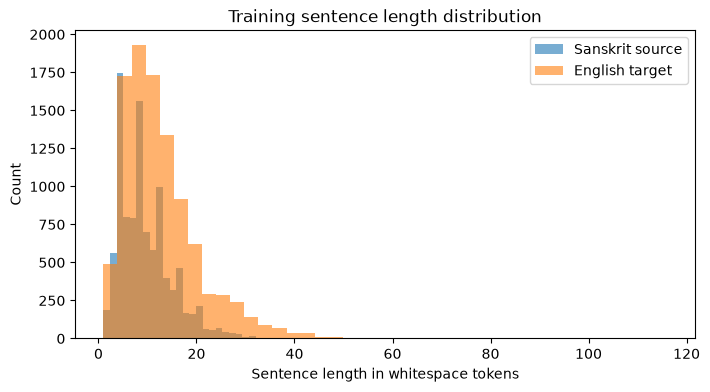

In [6]:
train_df["src_len"] = train_df["Sentence sa"].str.split().str.len()
train_df["tgt_len"] = train_df["Sentence en"].str.split().str.len()
print(train_df[["src_len", "tgt_len"]].describe())

plt.figure(figsize=(8, 4))
plt.hist(train_df["src_len"], bins=40, alpha=0.6, label="Sanskrit source")
plt.hist(train_df["tgt_len"], bins=40, alpha=0.6, label="English target")
plt.xlabel("Sentence length in whitespace tokens")
plt.ylabel("Count")
plt.title("Training sentence length distribution")
plt.legend()
plt.show()

In [7]:
# If a model requires login, run `huggingface-cli login` in terminal instead of hardcoding tokens.

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

print("Loading model...")
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME, trust_remote_code=True)
model.to(DEVICE)


ip = IndicProcessor(inference=False)
ip_infer = IndicProcessor(inference=True)


if USE_LORA:
    assert _PEFT_AVAILABLE, "USE_LORA=True but 'peft' is not installed. Run: pip install peft==0.11.1"
    print("Injecting LoRA adapters (parameter-efficient fine-tuning)...")
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_2_SEQ_LM,
        r=LORA_RANK,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=LORA_TARGET_MODULES,
    )
    model = get_peft_model(model, lora_config)
    model.to(DEVICE)

param_count = sum(p.numel() for p in model.parameters())
trainable_param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Model loaded:", MODEL_NAME)
print("Fine-tuning mode:", "LoRA (PEFT)" if USE_LORA else "full fine-tune")
print(f"Total parameters: {param_count:,}")
print(f"Trainable parameters: {trainable_param_count:,}")
if USE_LORA:
    print(f"Trainable fraction: {100.0 * trainable_param_count / param_count:.3f}%")


Loading tokenizer...


C:\Users\sunny\Downloads\NLU Assignment 2 - G25AIT1151\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading model...
Injecting LoRA adapters (parameter-efficient fine-tuning)...
Model loaded: ai4bharat/indictrans2-indic-en-dist-200M
Fine-tuning mode: LoRA (PEFT)
Total parameters: 224,756,736
Trainable parameters: 12,976,128
Trainable fraction: 5.773%


## Preprocessing and tokenisation
I normalise Unicode text before passing it into the IndicTrans processor. This keeps Devanagari text consistent and makes the training pipeline easier to reproduce.


In [8]:
# Dataset wrapper with IndicTrans preprocessing
def ip_preprocess_source(texts):
    return ip.preprocess_batch(
        batch=[normalize_text(x) for x in texts],
        src_lang=SRC_LANG,
        tgt_lang=TGT_LANG,
    )

def ip_preprocess_target(texts):
    
    texts = [normalize_text(x) for x in texts]
    try:
        return ip.preprocess_batch(
            batch=texts,
            src_lang=TGT_LANG,
            tgt_lang=SRC_LANG,
            is_target=True,
        )
    except TypeError:
        try:
            return ip.preprocess_batch(
                batch=texts,
                src_lang=TGT_LANG,
                is_target=True,
            )
        except TypeError:
            return ip.preprocess_batch(batch=texts, src_lang=TGT_LANG, tgt_lang=SRC_LANG)

def tokenize_parallel(src_texts, tgt_texts=None):
    src_processed = ip_preprocess_source(src_texts)
    model_inputs = tokenizer(
        src_processed,
        max_length=MAX_SOURCE_LENGTH,
        truncation=True,
        padding="max_length",
    )
    if tgt_texts is not None:
        tgt_processed = ip_preprocess_target(tgt_texts)
        labels = tokenizer(
            text_target=tgt_processed,
            max_length=MAX_TARGET_LENGTH,
            truncation=True,
            padding="max_length",
        )["input_ids"]
        labels = np.array(labels)
        labels[labels == tokenizer.pad_token_id] = -100
        model_inputs["labels"] = labels.tolist()
    return model_inputs

class TranslationDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self.enc = tokenize_parallel(self.df["Sentence sa"].tolist(), self.df["Sentence en"].tolist())

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.enc["input_ids"][idx], dtype=torch.long),
            "attention_mask": torch.tensor(self.enc["attention_mask"][idx], dtype=torch.long),
            "labels": torch.tensor(self.enc["labels"][idx], dtype=torch.long),
        }

train_dataset = TranslationDataset(train_df)
dev_dataset = TranslationDataset(dev_df)

train_loader = DataLoader(train_dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=True, pin_memory=torch.cuda.is_available())
dev_loader = DataLoader(dev_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False, pin_memory=torch.cuda.is_available())

print("Train batches:", len(train_loader))
print("Dev batches:", len(dev_loader))

Train batches: 2496
Dev batches: 250


In [9]:
# Assignment metrics and generation helper functions
def clean_prediction(text):
    text = str(text)
    text = re.sub(r"</?s>|<pad>", "", text)
    text = text.replace(TGT_LANG, "").replace(SRC_LANG, "")
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"\s+([.,!?;:])", r"\1", text)
    return text.strip()

def compute_nltk_bleu(predictions, references):
    refs = [[normalize_text(r).split()] for r in references]
    hyps = [normalize_text(p).split() for p in predictions]
    return float(corpus_bleu(refs, hyps))


_USE_CACHE = {"value": True}

@torch.no_grad()
def translate_texts(texts, batch_size=INFER_BATCH_SIZE, num_beams=NUM_BEAMS, max_new_tokens=MAX_NEW_TOKENS):
    model.eval()
    outputs_all = []
    start = time.perf_counter()
    for i in tqdm(range(0, len(texts), batch_size), desc="Translating"):
        batch = [normalize_text(x) for x in texts[i:i+batch_size]]
        
        processed = ip_infer.preprocess_batch(batch=batch, src_lang=SRC_LANG, tgt_lang=TGT_LANG)
        inputs = tokenizer(processed, return_tensors="pt", padding=True, truncation=True, max_length=MAX_SOURCE_LENGTH)
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        gen_kwargs = dict(
            num_beams=num_beams,
            max_new_tokens=max_new_tokens,
            length_penalty=LENGTH_PENALTY,
            no_repeat_ngram_size=NO_REPEAT_NGRAM_SIZE,
            early_stopping=True,
        )
        try:
            generated = model.generate(**inputs, use_cache=_USE_CACHE["value"], **gen_kwargs)
        except (RuntimeError, TypeError) as e:
            if _USE_CACHE["value"]:
                print("KV-cache generation failed; falling back to use_cache=False:", str(e)[:140])
                _USE_CACHE["value"] = False
                generated = model.generate(**inputs, use_cache=False, **gen_kwargs)
            else:
                raise
        decoded = tokenizer.batch_decode(generated, skip_special_tokens=True, clean_up_tokenization_spaces=True)
        
        decoded = ip_infer.postprocess_batch(decoded, lang=TGT_LANG)
        outputs_all.extend([clean_prediction(x) for x in decoded])
    elapsed = time.perf_counter() - start
    return outputs_all, elapsed

def evaluate_translation_set(df, name="dev", limit=None):
    eval_df = df if limit is None else df.head(limit)
    preds, elapsed = translate_texts(eval_df["Sentence sa"].tolist())
    refs = eval_df["Sentence en"].tolist()
    bleu = compute_nltk_bleu(preds, refs)
    print(f"{name} BLEU: {bleu:.6f} | translation time: {elapsed:.2f}s | n={len(eval_df)}")
    return bleu, preds, elapsed


In [10]:
# Optimizer and train/evaluate routines
import torch.nn as nn
no_decay = ["bias", "LayerNorm.weight", "layer_norm.weight"]

optimizer_grouped_parameters = [
    {
        "params": [p for n, p in model.named_parameters() if p.requires_grad and not any(nd in n for nd in no_decay)],
        "weight_decay": WEIGHT_DECAY,
    },
    {
        "params": [p for n, p in model.named_parameters() if p.requires_grad and any(nd in n for nd in no_decay)],
        "weight_decay": 0.0,
    },
]
optimizer = AdamW(optimizer_grouped_parameters, lr=EFFECTIVE_LR)

total_training_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = int(0.1 * total_training_steps)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_training_steps)
scaler = torch.amp.GradScaler("cuda", enabled=USE_FP16)

label_smoothing_criterion = nn.CrossEntropyLoss(ignore_index=-100, label_smoothing=LABEL_SMOOTHING)

print("Fine-tuning mode:", "LoRA (PEFT)" if USE_LORA else "full fine-tune")
print("Effective learning rate:", EFFECTIVE_LR)
print("Total training steps:", total_training_steps)
print("Warmup steps:", warmup_steps)
print("Mixed precision:", USE_FP16)

def train_one_epoch(epoch):
    model.train()
    total_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Training epoch {epoch}")
    for batch in pbar:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=USE_FP16):
            out = model(**batch)                       # labels passed so decoder inputs are built
            loss = label_smoothing_criterion(
                out.logits.reshape(-1, out.logits.size(-1)),
                batch["labels"].reshape(-1),
            )
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    return total_loss / len(train_loader)

@torch.no_grad()
def validate_loss():
    model.eval()
    total = 0.0
    for batch in tqdm(dev_loader, desc="Validation loss"):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out = model(**batch)
        total += out.loss.item()
    return total / len(dev_loader)


Fine-tuning mode: LoRA (PEFT)
Effective learning rate: 0.0003
Total training steps: 14976
Warmup steps: 1497
Mixed precision: True


## Fine-tuning strategy
I fine-tune conservatively because the dataset is small. The loop tracks development BLEU and keeps the best observed checkpoint rather than assuming that the last epoch is always best.


In [11]:
# Fine-tuning loop with dev BLEU checkpoint selection
import copy
import shutil

history = []
best_metric = -1.0
best_val_loss = float("inf")
best_state = None
early_stop_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    print("=" * 80)
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print("=" * 80)

    train_loss = train_one_epoch(epoch)
    val_loss = validate_loss()

    if EVAL_DEV_BLEU_EACH_EPOCH:
        dev_bleu, _, dev_bleu_time = evaluate_translation_set(dev_df, name=f"dev epoch {epoch}", limit=DEV_BLEU_LIMIT)
        selection_metric = dev_bleu
    else:
        dev_bleu, dev_bleu_time = None, None
        selection_metric = -val_loss

    row = {
        "epoch": epoch,
        "train_loss": float(train_loss),
        "val_loss": float(val_loss),
        "dev_bleu": None if dev_bleu is None else float(dev_bleu),
        "dev_bleu_time": None if dev_bleu_time is None else float(dev_bleu_time),
    }
    history.append(row)
    print(row)

    improved = selection_metric > best_metric
    if improved:
        best_metric = selection_metric
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        early_stop_counter = 0
        # In-loop safety checkpoint (adapters if LoRA, full model otherwise).
        model.save_pretrained(OUTPUT_DIR)
        tokenizer.save_pretrained(OUTPUT_DIR)
        print("Saved new best model.")
    else:
        early_stop_counter += 1
        print(f"No improvement: {early_stop_counter}/{PATIENCE}")
        if early_stop_counter >= PATIENCE:
            print("Early stopping.")
            break

# Restore the best weights observed during training.
if best_state is not None:
    model.load_state_dict(best_state)
    print("Best model restored in memory.")


if USE_LORA:
    print("Merging LoRA adapters into base weights...")
    model = model.merge_and_unload()
    model.to(DEVICE)
    if OUTPUT_DIR.exists():
        shutil.rmtree(OUTPUT_DIR)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print("Final best model written to:", OUTPUT_DIR.resolve())

pd.DataFrame(history)


Epoch 1/6


Training epoch 1:   0%|          | 0/2496 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/250 [00:00<?, ?it/s]

Translating:   0%|          | 0/125 [00:00<?, ?it/s]

dev epoch 1 BLEU: 0.230974 | translation time: 340.23s | n=1000
{'epoch': 1, 'train_loss': 2.930879203698192, 'val_loss': 1.6211964366436005, 'dev_bleu': 0.23097405411014624, 'dev_bleu_time': 340.2337036000099}
Saved new best model.
Epoch 2/6


...

Training epoch 6:   0%|          | 0/2496 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/250 [00:00<?, ?it/s]

Translating:   0%|          | 0/125 [00:00<?, ?it/s]

dev epoch 6 BLEU: 0.261132 | translation time: 271.98s | n=1000
{'epoch': 6, 'train_loss': 2.036900386739618, 'val_loss': 1.640634817123413, 'dev_bleu': 0.2611324324794426, 'dev_bleu_time': 271.9809837999928}
Saved new best model.
Best model restored in memory.
Merging LoRA adapters into base weights...
Final best model written to: C:\Users\sunny\Downloads\G25AIT1151_NLU_Neural_Machine_Translatiion_Assignment_v8\indictrans2_clean_best_model


,epoch,train_loss,val_loss,dev_bleu,dev_bleu_time
0,1,2.930879,1.621196,0.230974,340.233704
1,2,2.682464,1.561788,0.246532,300.893545
2,3,2.454195,1.549590,0.252969,288.129957
3,4,2.277164,1.573628,0.259439,280.857312
4,5,2.138324,1.600367,0.259816,277.265279
5,6,2.036900,1.640635,0.261132,271.980984


,epoch,train_loss,val_loss,dev_bleu,dev_bleu_time
0,1,2.930879,1.621196,0.230974,340.233704
1,2,2.682464,1.561788,0.246532,300.893545
2,3,2.454195,1.549590,0.252969,288.129957
3,4,2.277164,1.573628,0.259439,280.857312
4,5,2.138324,1.600367,0.259816,277.265279
5,6,2.036900,1.640635,0.261132,271.980984


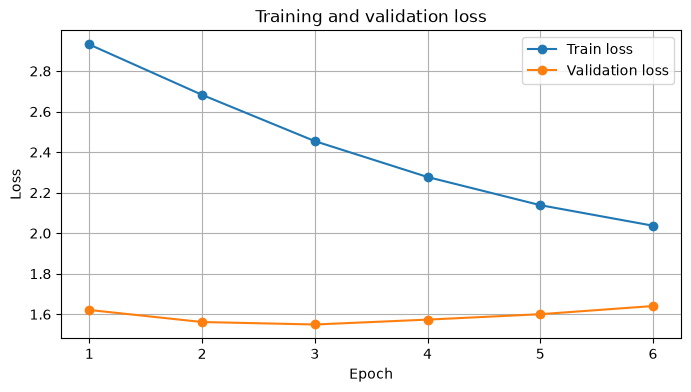

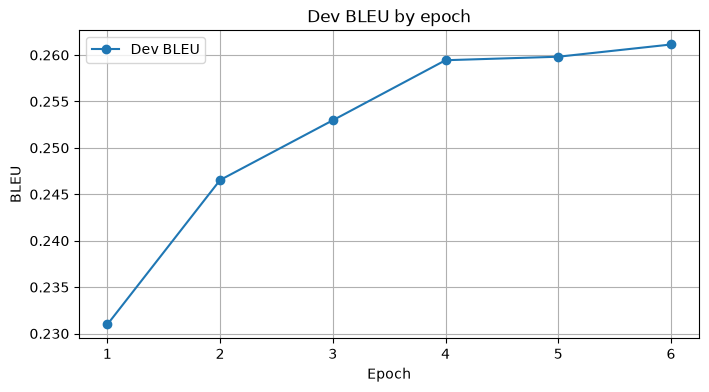

In [12]:
# Plot training curves for the report
hist_df = pd.DataFrame(history)
display(hist_df)

plt.figure(figsize=(8, 4))
plt.plot(hist_df["epoch"], hist_df["train_loss"], marker="o", label="Train loss")
plt.plot(hist_df["epoch"], hist_df["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.grid(True)
plt.legend()
plt.show()

if "dev_bleu" in hist_df and hist_df["dev_bleu"].notna().any():
    plt.figure(figsize=(8, 4))
    plt.plot(hist_df["epoch"], hist_df["dev_bleu"], marker="o", label="Dev BLEU")
    plt.xlabel("Epoch")
    plt.ylabel("BLEU")
    plt.title("Dev BLEU by epoch")
    plt.grid(True)
    plt.legend()
    plt.show()

## Load best fine-tuned checkpoint
Before evaluation and final inference I reload the best checkpoint saved during training from `OUTPUT_DIR`. This makes the evaluation path deterministic: on a fresh kernel you can run the setup cells and this cell (skipping the long training loop) and still evaluate the fine-tuned model instead of the base pretrained weights.


In [13]:

print("Loading best fine-tuned model from:", OUTPUT_DIR.resolve())

adapter_config = OUTPUT_DIR / "adapter_config.json"
if adapter_config.exists():
    print("Adapter checkpoint detected; loading base + adapters and merging...")
    base_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME, trust_remote_code=True)
    peft_model = PeftModel.from_pretrained(base_model, str(OUTPUT_DIR))
    model = peft_model.merge_and_unload()
else:
    model = AutoModelForSeq2SeqLM.from_pretrained(str(OUTPUT_DIR), trust_remote_code=True)

model.to(DEVICE)
model.eval()


param_count = sum(p.numel() for p in model.parameters())
try:
    trainable_param_count
except NameError:
    trainable_param_count = param_count
print(f"Total parameters: {param_count:,}")
print(f"Trainable parameters (training-time): {trainable_param_count:,}")
print("Best fine-tuned model ready for inference.")


Loading best fine-tuned model from: C:\Users\sunny\Downloads\G25AIT1151_NLU_Neural_Machine_Translatiion_Assignment_v8\indictrans2_clean_best_model


C:\Users\sunny\Downloads\NLU Assignment 2 - G25AIT1151\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Total parameters: 211,780,608
Trainable parameters (training-time): 12,976,128
Best fine-tuned model ready for inference.


In [14]:
# Development-set evaluation using assignment metrics
dev_predictions, dev_inference_time = translate_texts(dev_df["Sentence sa"].tolist(), batch_size=INFER_BATCH_SIZE)
dev_references = dev_df["Sentence en"].tolist()
dev_bleu = compute_nltk_bleu(dev_predictions, dev_references)

print("Dev BLEU:", dev_bleu)
print("Dev inference time:", dev_inference_time)

P, R, F1 = bertscore(dev_predictions, dev_references, lang="en", rescale_with_baseline=True, verbose=True)
dev_bertscore_f1 = float(F1.mean().item())
print("Dev BERTScore F1:", dev_bertscore_f1)

Translating:   0%|          | 0/125 [00:00<?, ?it/s]

Dev BLEU: 0.2611324324794426
Dev inference time: 128.6906270000036


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


  0%|          | 0/31 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 6.80 seconds, 147.11 sentences/sec
Dev BERTScore F1: 0.6212829351425171


C:\Users\sunny\Downloads\NLU Assignment 2 - G25AIT1151\.venv\Lib\site-packages\bert_score\score.py:149: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  baselines = torch.from_numpy(


In [15]:

examples = pd.DataFrame({
    "Source": dev_df["Sentence sa"].head(10),
    "Reference": dev_references[:10],
    "Prediction": dev_predictions[:10],
})
display(examples)

,Source,Reference,Prediction
0,ते वीराः ।,Those are brave men.,Those two are heroes.
1,'इन्फ़ैनेट् लूप्' इतीदं व्यवस्थां निरुत्तरां क...,Infinite loop can cause the system to become u...,The infinite loop makes the system smooth.
2,ततस्तस्य गात्रे निष्ठीवं दत्वा तेन वेत्रेण शिर...,"""And they spit upon him, and took the reed, an...","""And they laid hold on him, and bowed their he..."
3,एते तिथी ।,These two are dates.,These are dates.
4,"""बहुविचारेषु जातषु पितर उत्थाय कथितवान्, हे भ्...","""And when there had been much disputing, Peter...","""After much deliberation Peter arose, and said..."
5,यूयं भक्तियोगं पठथ।,You all are studying bhakti yoga.,You all read bhakti yoga.
6,voidइति मेथड् नाम टङ्कयतु ।,"So, type: void name of the method",Type the method name as void.
7,"पाठेऽस्मिन् वयम्, awk इत्यस्मिन् if, else, els...","In this tutorial, we will learn about- if, els...","In this tutorial, we will learn about if, else..."
8,नूनम् ईषत् ‘S’ इति वक्रं तस्य उपरि स्थापयतु । ...,Just put a slight ‘S’ curve on it and I think ...,Just place the curve'S'on it and I think this ...
9,पुन: स्वस्थितौ आगच्छेत ।,• Come back to Sthiti.,Again come back to your original position.


## Final test generation
The test translations are generated only after model selection. The output format is kept exactly as required: `Source id` and `Sentence en`.


In [16]:
# Generate final test translations and submission.csv
test_predictions, test_inference_time = translate_texts(test_df["Sentence sa"].tolist(), batch_size=INFER_BATCH_SIZE)

submission = pd.DataFrame({
    "Source_id": test_df["Source id"],
    "Sentence_en": test_predictions,
})
submission.to_csv("submission.csv", index=False, encoding="utf-8")

print("Saved submission.csv")
print("Test inference time:", test_inference_time)
print(submission.head())

Translating:   0%|          | 0/125 [00:00<?, ?it/s]

Saved submission.csv
Test inference time: 140.77401149997604
   Source_id                                        Sentence_en
0          1  Eclipse also helps the programmer in error det...
1          2  "For I speak as of faith. As it is written, We...
2          3  It will then search for its own driver. I will...
3          4  For all iterations, this means that the iterat...
4          5  "And I heard him say, The second spirit cometh...


## Metric reporting
The assignment uses NLTK corpus BLEU, BERTScore F1, inference time, and parameter count, so I calculate and save all of them in one metrics file.


In [17]:
# Public test metrics when references are available
metrics = {
    "model_name": MODEL_NAME,
    "src_lang": SRC_LANG,
    "tgt_lang": TGT_LANG,
    "use_lora": bool(USE_LORA),
    "lora_rank": int(LORA_RANK) if USE_LORA else None,
    "lora_alpha": int(LORA_ALPHA) if USE_LORA else None,
    "num_train_sentences": int(len(train_df)),
    "num_dev_sentences": int(len(dev_df)),
    "num_test_sentences": int(len(test_df)),
    "total_parameters": int(param_count),
    "trainable_parameters": int(trainable_param_count),
    "num_epochs_configured": int(NUM_EPOCHS),
    "learning_rate": float(EFFECTIVE_LR),
    "train_batch_size": int(TRAIN_BATCH_SIZE),
    "infer_batch_size": int(INFER_BATCH_SIZE),
    "num_beams": int(NUM_BEAMS),
    "max_new_tokens": int(MAX_NEW_TOKENS),
    "length_penalty": float(LENGTH_PENALTY),
    "no_repeat_ngram_size": int(NO_REPEAT_NGRAM_SIZE),
    "dev_bleu": float(dev_bleu),
    "dev_bertscore_f1": float(dev_bertscore_f1),
    "dev_inference_time_seconds": float(dev_inference_time),
    "test_inference_time_seconds": float(test_inference_time),
}

if test_en_path is not None:
    test_en = standardise_en(read_csv_flexible(test_en_path))
    gold = test_en.copy()
    pred = submission.copy()
    gold = gold.rename(columns={"Source id": "Source_id", "Sentence en": "Sentence_en"})
    merged = pred.merge(gold, on="Source_id", how="inner", suffixes=("_pred", "_gold"))
    test_bleu = compute_nltk_bleu(merged["Sentence_en_pred"].tolist(), merged["Sentence_en_gold"].tolist())
    print("Public test merged rows:", len(merged))
    print("Public test BLEU:", test_bleu)
    P, R, F1 = bertscore(merged["Sentence_en_pred"].tolist(), merged["Sentence_en_gold"].tolist(), lang="en", rescale_with_baseline=True, verbose=True)
    test_bertscore_f1 = float(F1.mean().item())
    print("Public test BERTScore F1:", test_bertscore_f1)
    metrics["test_bleu"] = float(test_bleu)
    metrics["test_bertscore_f1"] = float(test_bertscore_f1)
else:
    print("test_en file not found. Private evaluation mode: test BLEU/BERTScore skipped.")

with open("metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print(json.dumps(metrics, indent=2, ensure_ascii=False))
print("Saved metrics.json")


Public test merged rows: 1000
Public test BLEU: 0.25009379004834564


C:\Users\sunny\Downloads\NLU Assignment 2 - G25AIT1151\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


  0%|          | 0/30 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 6.22 seconds, 160.69 sentences/sec
Public test BERTScore F1: 0.6215803623199463
{
  "model_name": "ai4bharat/indictrans2-indic-en-dist-200M",
  "src_lang": "san_Deva",
  "tgt_lang": "eng_Latn",
  "use_lora": true,
  "lora_rank": 32,
  "lora_alpha": 64,
  "num_train_sentences": 9982,
  "num_dev_sentences": 1000,
  "num_test_sentences": 1000,
  "total_parameters": 211780608,
  "trainable_parameters": 12976128,
  "num_epochs_configured": 6,
  "learning_rate": 0.0003,
  "train_batch_size": 4,
  "infer_batch_size": 8,
  "num_beams": 5,
  "max_new_tokens": 128,
  "length_penalty": 1.0,
  "no_repeat_ngram_size": 0,
  "dev_bleu": 0.2611324324794426,
  "dev_bertscore_f1": 0.6212829351425171,
  "dev_inference_time_seconds": 128.6906270000036,
  "test_inference_time_seconds": 140.77401149997604,
  "test_bleu": 0.25009379004834564,
  "test_bertscore_f1": 0.6215803623199463
}
Saved metrics.json


In [18]:
# Final output checklist
print("Required output files created:")
print("- submission.csv")
print("- metrics.json")
print("- model directory:", OUTPUT_DIR)
print()
print("submission.csv columns:", list(pd.read_csv("submission.csv", nrows=1).columns))
print("Expected columns: ['Source_id', 'Sentence_en']")

Required output files created:
- submission.csv
- metrics.json
- model directory: indictrans2_clean_best_model

submission.csv columns: ['Source_id', 'Sentence_en']
Expected columns: ['Source_id', 'Sentence_en']
